In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [2]:
import sys
!{sys.executable} -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [7]:
df = pd.read_csv(r"D:\Internship\P1\Level 1\Task 2\Customer Segmentation Analysis\Online Retail.csv")

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 541909
Number of columns: 8


In [10]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [11]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
df = df.dropna(subset=['CustomerID', 'Description'])

df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [15]:
df.shape

(406829, 8)

In [16]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(8905)

In [13]:
(df['Quantity'] <= 0).sum()

np.int64(8905)

In [14]:
(df['UnitPrice'] <= 0).sum()

np.int64(40)

In [17]:
df = df[
    (~df['InvoiceNo'].astype(str).str.startswith('C')) &
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
]

df.shape

(397884, 8)

In [18]:
df.duplicated().sum()

np.int64(5192)

In [20]:
df = df.drop_duplicates()

df.shape

(392692, 8)

In [21]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,15287.843865
std,180.492832,22.241836,1713.539549
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13955.000000
50%,6.000000,1.950000,15150.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,8142.750000,18287.000000


In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['InvoiceDate'].dtype

dtype('<M8[us]')

In [23]:
print("Minimum Date:", df['InvoiceDate'].min())
print("Maximum Date:", df['InvoiceDate'].max())

Minimum Date: 2010-12-01 08:26:00
Maximum Date: 2011-12-09 12:50:00


In [24]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [8]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [9]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [10]:
rfm.shape

(4338, 3)

In [11]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


## RFM Distribution Analysis

Before applying clustering, we examine the distributions of the RFM features. This helps identify differences in customer purchasing behavior and detect skewness or extreme values.

Histograms are used to visualize the distributions of Recency, Frequency, and Monetary values.


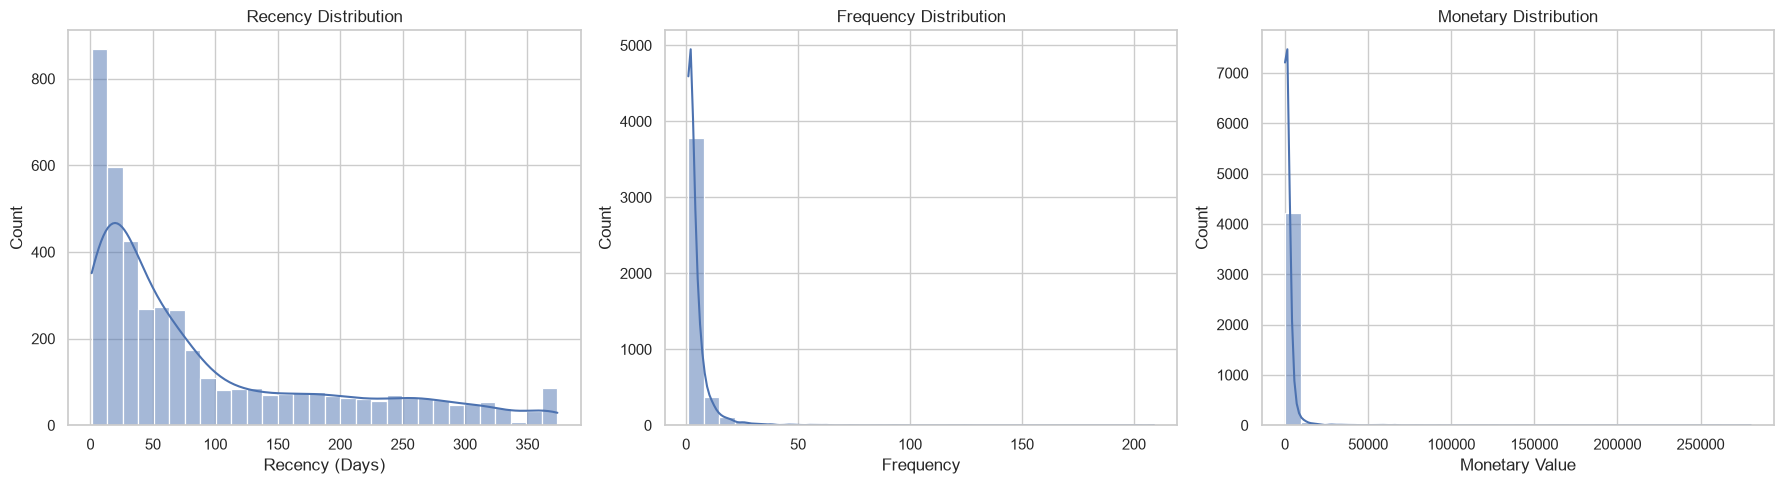

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Recency (Days)')

sns.histplot(rfm['Frequency'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Frequency')

sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Monetary Value')

plt.tight_layout()
plt.show()

## Feature Standardization

K-Means clustering is distance-based, so features with larger numerical ranges can have a greater influence on the clustering results.

To give Recency, Frequency, and Monetary equal importance, the RFM features are standardized using `StandardScaler`. After scaling, each feature has approximately a mean of 0 and a standard deviation of 1.


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


In [30]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,2.293130e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.276151e-01
25%,-7.453445e-01,-4.250965e-01,-1.939190e-01
50%,-4.153533e-01,-2.951776e-01,-1.536162e-01
75%,4.946227e-01,9.457903e-02,-4.319704e-02
max,2.814561e+00,2.659803e+01,3.096074e+01


In [31]:
df.to_csv(
    r"D:\Internship\P1\Level 1\Task 2\Customer Segmentation Analysis\Online Retail_v1.csv",
    index=False
)

In [3]:
df = pd.read_csv(r"D:\Internship\P1\Level 1\Task 2\Customer Segmentation Analysis\Online Retail_v1.csv")

## Determining the Optimal Number of Clusters

The Elbow Method is used to determine a suitable number of clusters for K-Means clustering.

It calculates the Within-Cluster Sum of Squares (WCSS), also called inertia, for different values of K. As the number of clusters increases, the inertia decreases. The point where the decrease starts to slow down significantly is considered the "elbow" and is selected as the optimal number of clusters.


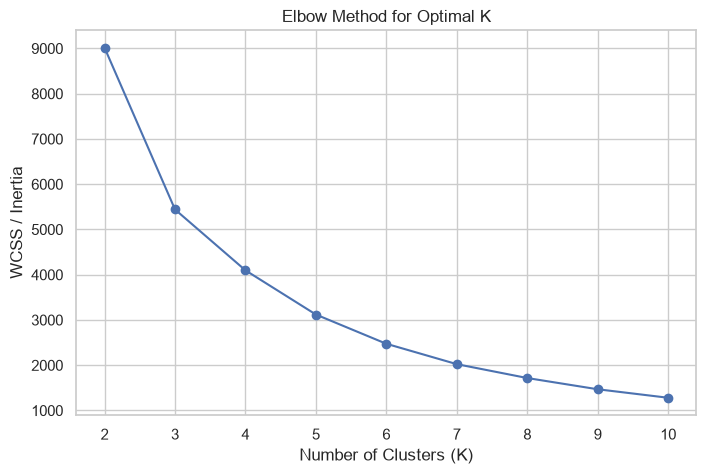

In [14]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

## K-Means Clustering

Based on the Elbow Method, **K = 4** is selected as the optimal number of clusters. K-Means clustering is applied to the standardized RFM features to divide customers into four groups with similar purchasing behavior.

A fixed `random_state` is used to make the clustering results reproducible.


In [15]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [16]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

## Customer Cluster Profiling

To understand the characteristics of each customer segment, the average Recency, Frequency, and Monetary values are calculated for every cluster.

These average values help identify the purchasing behavior of each segment and provide a basis for assigning meaningful customer segment names and developing targeted marketing strategies.


In [17]:
cluster_profile = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [18]:
cluster_median = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].median().round(2)

cluster_median

,Recency,Frequency,Monetary
Cluster,,,
0,32.0,3.0,826.27
1,243.0,1.0,310.26
2,2.0,63.0,117210.08
3,5.0,19.0,7990.20


## Customer Segment Classification

Based on the cluster profiles, meaningful customer segment names are assigned to make the results easier to interpret for marketing purposes.

The segments are classified according to customer recency, purchase frequency, and total monetary value.


In [19]:
segment_names = {
    0: 'Regular Customers',
    1: 'At-Risk / Low-Value Customers',
    2: 'VIP / Extremely High-Value Customers',
    3: 'High-Value Loyal Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,High-Value Loyal Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,At-Risk / Low-Value Customers


In [20]:
rfm['Segment'].value_counts()

Segment
Regular Customers                       3054
At-Risk / Low-Value Customers           1067
High-Value Loyal Customers               204
VIP / Extremely High-Value Customers      13
Name: count, dtype: int64

## Cluster Visualization

Scatter plots are used to visualize the separation between customer segments based on different combinations of RFM features.

Two feature combinations are examined:

* **Frequency vs Monetary:** shows the relationship between purchase frequency and customer spending.
* **Recency vs Monetary:** shows how recent purchases relate to customer spending.

The cluster labels are represented using different colors to make the customer segments easier to compare.


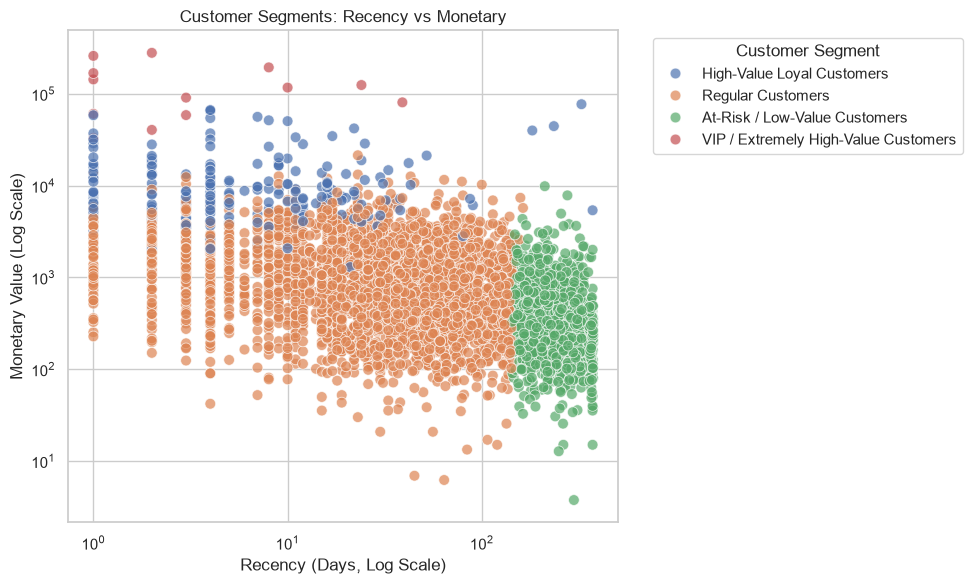

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    s=60,
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days, Log Scale)')
plt.ylabel('Monetary Value (Log Scale)')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

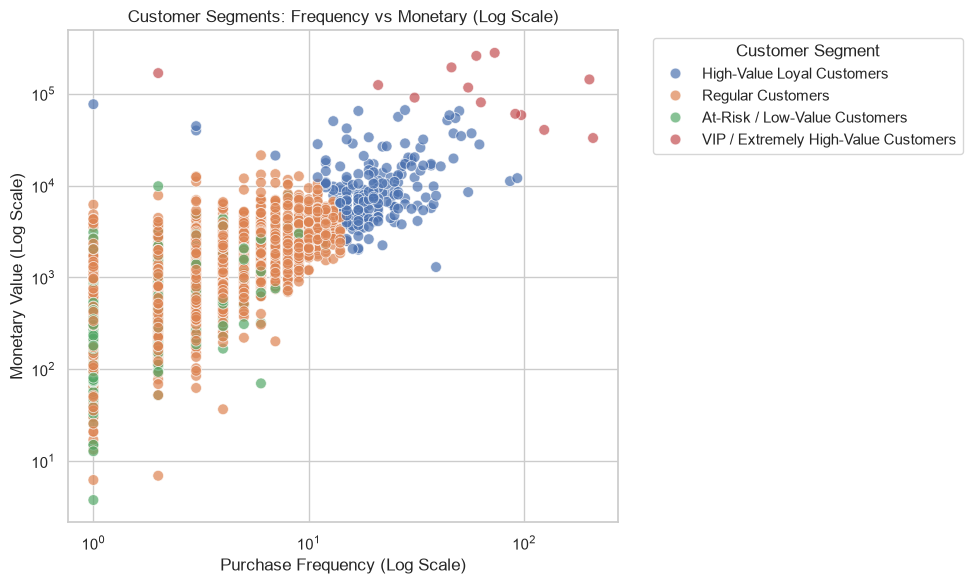

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    s=60,
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')

plt.title('Customer Segments: Frequency vs Monetary (Log Scale)')
plt.xlabel('Purchase Frequency (Log Scale)')
plt.ylabel('Monetary Value (Log Scale)')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

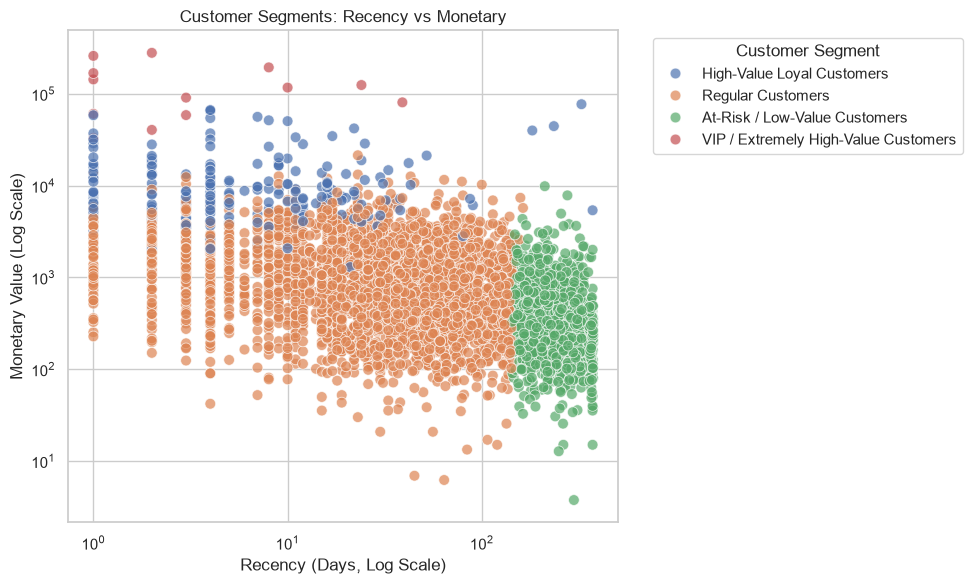

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    s=60,
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days, Log Scale)')
plt.ylabel('Monetary Value (Log Scale)')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Customer Distribution by Segment

The number of customers in each segment is visualized using a bar chart. This helps identify the size of each customer group and shows how the customer base is distributed across the identified segments.


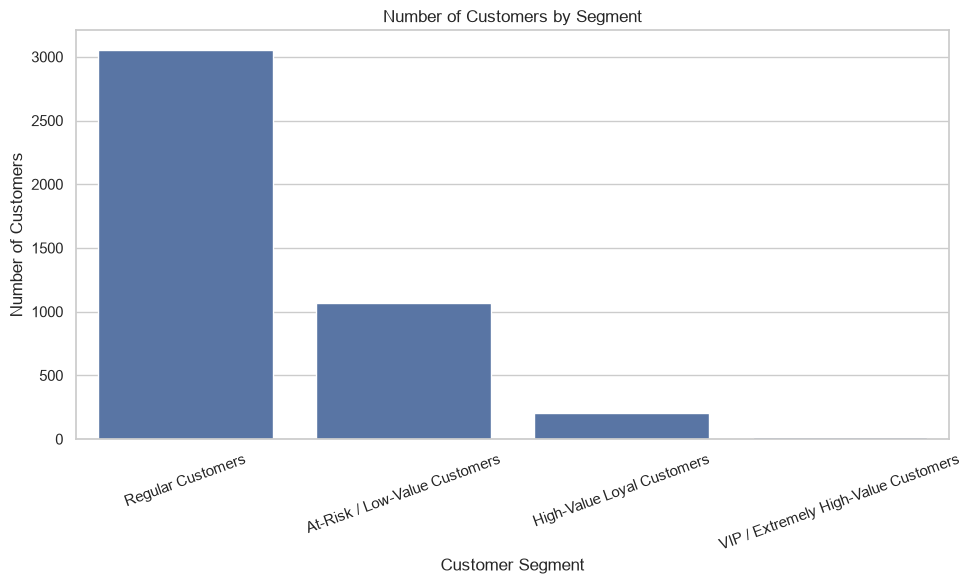

In [25]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=rfm,
    x='Segment',
    order=rfm['Segment'].value_counts().index
)

plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Marketing Insights and Recommendations

The customer segments show clear differences in purchasing behavior. Targeted marketing strategies can be developed for each segment based on their recency, frequency, and monetary value.

### 1. Regular Customers

These customers form the largest segment and show moderate purchasing frequency and spending. They are reasonably active but have potential for further engagement.

**Recommended actions:**

* Offer personalized product recommendations.
* Use loyalty rewards to encourage repeat purchases.
* Provide cross-selling and upselling offers.
* Send targeted promotions based on previous purchases.

### 2. At-Risk / Low-Value Customers

These customers have high recency values, meaning they have not purchased recently. They also have relatively low purchase frequency and monetary value.

**Recommended actions:**

* Send re-engagement emails and personalized offers.
* Provide limited-time discounts to encourage a return purchase.
* Recommend products based on their previous purchases.
* Use reminder campaigns to bring inactive customers back.

### 3. High-Value Loyal Customers

These customers purchase frequently, spend considerably, and have purchased recently. They represent an important group for customer retention.

**Recommended actions:**

* Provide loyalty rewards and exclusive benefits.
* Offer early access to new products.
* Use personalized recommendations.
* Encourage referrals and repeat purchases.

### 4. VIP / Extremely High-Value Customers

This is a very small but exceptionally valuable segment with very high purchase frequency and monetary value and very recent activity.

**Recommended actions:**

* Provide premium loyalty programs and exclusive privileges.
* Assign personalized customer support where appropriate.
* Offer early access to premium products and special events.
* Focus on retention rather than heavy discounting.
* Build long-term relationships through personalized communication.

These strategies can help improve customer retention, increase repeat purchases, and maximize customer lifetime value.


## Conclusion

RFM analysis and K-Means clustering were used to segment 4,338 e-commerce customers based on their purchasing behavior. After cleaning the transaction data, Recency, Frequency, and Monetary features were created and standardized before applying K-Means clustering.

The Elbow Method indicated that four clusters provided a suitable segmentation. The resulting segments were identified as Regular Customers, At-Risk / Low-Value Customers, High-Value Loyal Customers, and VIP / Extremely High-Value Customers.

The segmentation provides actionable insights for targeted marketing. Regular customers can be encouraged to purchase more frequently, at-risk customers can be targeted with re-engagement campaigns, loyal customers can be rewarded to strengthen retention, and VIP customers can receive personalized premium treatment.

Overall, customer segmentation helps the business understand different purchasing behaviors and develop more effective, targeted marketing strategies.
